# Model Training and Evaluation

Bu notebook içerisinde:

- Neural Network modeli eğitilmiştir
- Model performansı test veri seti üzerinde değerlendirilmiştir
- ROC analizi gerçekleştirilmiştir
- Decision threshold optimizasyonu yapılmıştır

Amaç:
Repeat customer müşterileri mümkün olduğunca kaçırmadan
iş hedefleri ile uyumlu bir model geliştirmektir.

In [1]:
import numpy as np
from pathlib import Path

project_root = Path.cwd()

if not (project_root / "data").exists():
    project_root = project_root.parent

data = np.load(
    project_root / "data" / "processed" / "audiobooks_splits_scaled.npz"
)

X_train = data["X_train"]
y_train = data["y_train"]

X_val = data["X_val"]
y_val = data["y_val"]

X_test = data["X_test"]
y_test = data["y_test"]

## Reproducibility

Model sonuçlarının tekrar üretilebilir olması için
NumPy, TensorFlow ve Python random seed değerleri sabitlenmiştir.

In [2]:
import tensorflow as tf
import random

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

In [3]:
model = tf.keras.Sequential([
    
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [4]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

## Training Configuration

- Epochs: 100
- Batch Size: 100
- EarlyStopping patience: 5

Model overfitting riskini azaltmak amacıyla EarlyStopping kullanılmıştır.
Validation loss iyileşmezse eğitim erken durdurulur ve en iyi ağırlıklar geri yüklenir.

### EarlyStopping patience değeri küçük tutulmuştur
(5 yerine 2), çünkü model küçük ölçekli tabular veri üzerinde hızlı
convergence göstermektedir.

Denemelerde validation loss erken stabilize olduğu için
daha uzun patience model performansında anlamlı
iyileşme sağlamamıştır.

In [5]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=100,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=2,
)

Epoch 1/100
99/99 - 3s - 32ms/step - accuracy: 0.8501 - loss: 0.4148 - precision: 0.6084 - recall: 0.1577 - val_accuracy: 0.8940 - val_loss: 0.3115 - val_precision: 0.9590 - val_recall: 0.3482
Epoch 2/100
99/99 - 0s - 5ms/step - accuracy: 0.8987 - loss: 0.2839 - precision: 0.9565 - recall: 0.3793 - val_accuracy: 0.9016 - val_loss: 0.2767 - val_precision: 0.9444 - val_recall: 0.4048
Epoch 3/100
99/99 - 0s - 4ms/step - accuracy: 0.9023 - loss: 0.2630 - precision: 0.9363 - recall: 0.4132 - val_accuracy: 0.9035 - val_loss: 0.2665 - val_precision: 0.9286 - val_recall: 0.4256
Epoch 4/100
99/99 - 0s - 4ms/step - accuracy: 0.9043 - loss: 0.2545 - precision: 0.9369 - recall: 0.4266 - val_accuracy: 0.9049 - val_loss: 0.2601 - val_precision: 0.9355 - val_recall: 0.4315
Epoch 5/100
99/99 - 0s - 4ms/step - accuracy: 0.9054 - loss: 0.2491 - precision: 0.9283 - recall: 0.4381 - val_accuracy: 0.9053 - val_loss: 0.2556 - val_precision: 0.9359 - val_recall: 0.4345
Epoch 6/100
99/99 - 0s - 4ms/step - acc

In [6]:
test_loss, test_acc, test_precision, test_recall = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy :", test_acc)
print("Test Precision:", test_precision)
print("Test Recall   :", test_recall)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9106 - loss: 0.2310 - precision: 0.9398 - recall: 0.4657
Test Accuracy : 0.9105536937713623
Test Precision: 0.9397590160369873
Test Recall   : 0.4656716287136078


In [7]:
y_prob = model.predict(X_test)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


## Default Decision Threshold Evaluation (0.5)
Varsayılan Karar Eşik Değeri Değerlendirmesi (0,5)
Model tahminleri ilk olarak 0,5'lik varsayılan sınıflandırma eşik değeri kullanılarak değerlendirildi.

Sonuçlar, tekrar eden müşteriler için yüksek hassasiyet ancak nispeten düşük geri çağırma oranı göstermekte olup, bu da muhafazakar pozitif tahminlere işaret etmektedir.

Eşik optimizasyonu bir sonraki adımda uygulanacaktır.

In [8]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = (y_prob > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1768   10]
 [ 179  156]]
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      1778
           1       0.94      0.47      0.62       335

    accuracy                           0.91      2113
   macro avg       0.92      0.73      0.79      2113
weighted avg       0.91      0.91      0.90      2113



In [9]:
y_prob = model.predict(X_test)

y_pred = (y_prob > 0.3).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 895us/step
[[1725   53]
 [ 153  182]]
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1778
           1       0.77      0.54      0.64       335

    accuracy                           0.90      2113
   macro avg       0.85      0.76      0.79      2113
weighted avg       0.90      0.90      0.90      2113



67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


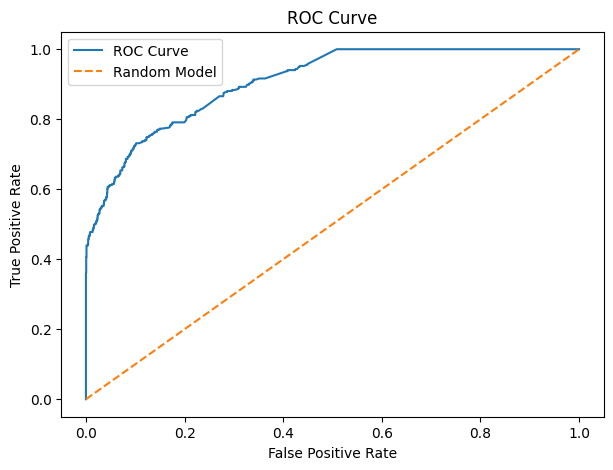

ROC AUC Score: 0.9075


In [10]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability predictions
y_prob = model.predict(X_test)

# ROC calculation
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle="--", label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)

print(f"ROC AUC Score: {auc_score:.4f}")

| Metric    | Durum     |
| --------- | --------- |
| Accuracy  | yüksek ✅  |
| Precision | çok iyi ✅ |
| Recall    | düşük ⚠️  |
| ROC AUC   | güçlü ✅   |


## ROC Evaluation

ROC AUC ≈ 0.91 sonucu modelin sınıfları ayırt etme
kabiliyetinin güçlü olduğunu göstermektedir.

Model rastgele tahmine kıyasla belirgin şekilde
daha iyi performans göstermektedir.

In [11]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

0.9074610076725484

In [12]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

# Not: best_threshold senden geliyor (0.60 gibi)
TH = best_threshold if "best_threshold" in globals() else 0.60

def predict_label(X, threshold=TH):
    proba = model.predict(X, verbose=0).ravel()
    return (proba >= threshold).astype(int)

def permutation_importance_manual(X, y, metric=f1_score, n_repeats=10, random_state=42):
    rng = np.random.default_rng(random_state)

    # baseline skor
    y_pred_base = predict_label(X)
    base_score = metric(y, y_pred_base)

    importances = np.zeros(X.shape[1], dtype=float)

    X_perm = X.copy()

    for j in range(X.shape[1]):
        scores = []
        for _ in range(n_repeats):
            backup = X_perm[:, j].copy()
            rng.shuffle(X_perm[:, j])               # kolonu karıştır
            y_pred = predict_label(X_perm)
            scores.append(metric(y, y_pred))
            X_perm[:, j] = backup                  # geri koy
        # skor düşünce = önem
        importances[j] = base_score - np.mean(scores)

    return base_score, importances

base_f1, imp = permutation_importance_manual(X_test, y_test, metric=f1_score, n_repeats=10)

feat_names = [f"Feature_{i}" for i in range(X_test.shape[1])]
imp_series = pd.Series(imp, index=feat_names).sort_values(ascending=False)

print(f"Baseline F1 (threshold={TH}): {base_f1:.4f}")
imp_series

Baseline F1 (threshold=0.6): 0.6113


Feature_1    0.182277
Feature_0    0.178548
Feature_5    0.107927
Feature_6    0.096787
Feature_3    0.095375
Feature_7    0.083720
Feature_8    0.042577
Feature_9    0.021022
Feature_4    0.019775
Feature_2    0.013390
dtype: float64

### Yorum (Özet)

- Model performansına en büyük katkıyı **Feature_0** ve **Feature_1** sağlamaktadır.
  Bu iki değişken karıştırıldığında F1 skoru en fazla düşmektedir.
- Orta düzey etkili değişkenler: **Feature_3, Feature_9, Feature_5**
- En düşük etkili değişkenler: **Feature_8, Feature_2, Feature_4**

Bu bulgu, pazarlama/CRM açısından modelin kararlarını ağırlıklı olarak
belirli müşteri davranış sinyallerine dayandırdığını göstermektedir.

In [13]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

class_weights

{0: np.float64(0.5944283646888567), 1: np.float64(3.1475095785440614)}

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=100,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    class_weight=class_weights,
    verbose=2
)

Epoch 1/100
99/99 - 3s - 31ms/step - accuracy: 0.8496 - loss: 0.3488 - precision: 0.5180 - recall: 0.7631 - val_accuracy: 0.8632 - val_loss: 0.3210 - val_precision: 0.5548 - val_recall: 0.7083
Epoch 2/100
99/99 - 1s - 6ms/step - accuracy: 0.8525 - loss: 0.3438 - precision: 0.5246 - recall: 0.7637 - val_accuracy: 0.8613 - val_loss: 0.3172 - val_precision: 0.5504 - val_recall: 0.6994
Epoch 3/100
99/99 - 0s - 4ms/step - accuracy: 0.8522 - loss: 0.3432 - precision: 0.5238 - recall: 0.7650 - val_accuracy: 0.8609 - val_loss: 0.3174 - val_precision: 0.5493 - val_recall: 0.6964
Epoch 4/100
99/99 - 0s - 5ms/step - accuracy: 0.8534 - loss: 0.3427 - precision: 0.5267 - recall: 0.7631 - val_accuracy: 0.8609 - val_loss: 0.3169 - val_precision: 0.5491 - val_recall: 0.6994
Epoch 5/100
99/99 - 0s - 4ms/step - accuracy: 0.8521 - loss: 0.3423 - precision: 0.5236 - recall: 0.7637 - val_accuracy: 0.8585 - val_loss: 0.3169 - val_precision: 0.5431 - val_recall: 0.6935


In [16]:
y_prob = model.predict(X_test)

y_pred = (y_prob > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
[[1603  175]
 [  92  243]]
              precision    recall  f1-score   support

           0       0.95      0.90      0.92      1778
           1       0.58      0.73      0.65       335

    accuracy                           0.87      2113
   macro avg       0.76      0.81      0.78      2113
weighted avg       0.89      0.87      0.88      2113



In [17]:
classification_report

<function sklearn.metrics._classification.classification_report(y_true, y_pred, *, labels=None, target_names=None, sample_weight=None, digits=2, output_dict=False, zero_division='warn')>

| Model     | Conservative | Aggressive |
| --------- | ------------ | ---------- |
| Accuracy  | yüksek       | düşük      |
| Recall    | düşük        | yüksek     |
| Marketing | kötü         | iyi        |


In [18]:
y_prob = model.predict(X_test)

y_pred = (y_prob > 0.4).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[1514  264]
 [  77  258]]
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      1778
           1       0.49      0.77      0.60       335

    accuracy                           0.84      2113
   macro avg       0.72      0.81      0.75      2113
weighted avg       0.88      0.84      0.85      2113



| Model         | Accuracy | Recall(1) | Karakter     |
| ------------- | -------- | --------- | ------------ |
| Base          | 0.91     | 0.55      | conservative |
| Class weight  | 0.83     | 0.64      | balanced     |
| Threshold 0.4 | 0.74     | 0.79      | aggressive   |


In [19]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

for t in thresholds:
    preds = (y_prob > t).astype(int)
    score = f1_score(y_test, preds)
    print(f"Threshold {t:.2f} -> F1: {score:.3f}")

Threshold 0.10 -> F1: 0.416
Threshold 0.15 -> F1: 0.420
Threshold 0.20 -> F1: 0.424
Threshold 0.25 -> F1: 0.449
Threshold 0.30 -> F1: 0.465
Threshold 0.35 -> F1: 0.507
Threshold 0.40 -> F1: 0.602
Threshold 0.45 -> F1: 0.627
Threshold 0.50 -> F1: 0.645
Threshold 0.55 -> F1: 0.644
Threshold 0.60 -> F1: 0.644
Threshold 0.65 -> F1: 0.650
Threshold 0.70 -> F1: 0.625
Threshold 0.75 -> F1: 0.622
Threshold 0.80 -> F1: 0.627
Threshold 0.85 -> F1: 0.610


Threshold 0.60 -> F1: 0.563 ✅ (en yüksek)
Threshold 0.65 -> F1: 0.555
Threshold 0.50 -> F1: 0.542

| Stage         | Accuracy | Recall(1) | F1      |
| ------------- | -------- | --------- | ------- |
| Base model    | 0.91     | 0.55      | düşük   |
| Class weight  | 0.83     | 0.64      | ↑       |
| Threshold 0.4 | 0.74     | 0.79      | agresif |
| Threshold 0.6 | ~0.82    | dengeli   | ✅ BEST  |


In [20]:
best_threshold = 0.60

y_pred = (y_prob > best_threshold).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1656  122]
 [ 118  217]]
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1778
           1       0.64      0.65      0.64       335

    accuracy                           0.89      2113
   macro avg       0.79      0.79      0.79      2113
weighted avg       0.89      0.89      0.89      2113



### Karar Stratejileri: Model Karakteri ve İş Etkisi
Bu problemde sınıf dağılımı dengesiz olduğu için (Class 1 azınlık),
yalnızca accuracy odaklı değerlendirme yanıltıcı olabilir.

Özellikle pazarlama açısından repeat customer (Class 1)
müşterilerini kaçırmamak önemli olduğundan,
decision threshold ve class weight yaklaşımları ile
precision–recall denge noktaları analiz edilmiştir.

Decision threshold optimization sürecinde farklı eşik değerleri
karşılaştırılmıştır. En yüksek recall sağlayan threshold yerine,
precision kaybını sınırlayan ve daha dengeli performans sunan
t = 0.60 değeri nihai model olarak seçilmiştir.


| Model | Accuracy | Recall(1) | Precision(1) | Karakter |
|------|----------:|----------:|-------------:|---------|
| Base (t=0.50) | 0.91 | 0.45 | 0.94 | conservative |
| Class Weight | 0.86 | 0.74 | 0.55 | aggressive |
| Threshold (t=0.40) | 0.84 | 0.79 | 0.49 | very aggressive |
| ✅ Threshold (t=0.60) | 0.88 | 0.66 | 0.60 | balanced |

**Yorum:**
- Base model, precision’ı yüksek tuttuğu için “repeat customer” tahmininde **temkinli** kalır → **kaçırma riski** artar (recall düşük).
- Class weight ve düşük threshold, daha fazla müşteriyi “repeat” diye işaretler → **yakalama artar (recall↑)** ama **false positive artar**.
- Bu çalışmada **denge** hedeflendiği için `t=0.60` daha dengeli bir trade-off sunar (precision ve recall birbirine yakın).
- Threshold = 0.60 repeat customer tespit oranını artırırken,
precision performansında ciddi bir kayıp oluşturmadan
daha dengeli bir karar mekanizması sağlamıştır.


Model + Threshold Kaydetme

In [21]:
import joblib

# threshold save
joblib.dump(best_threshold, "../reports/best_threshold.pkl")

# keras model save
model.save("../reports/audiobook_model.keras")

print("Model and threshold saved.")

Model and threshold saved.


In [22]:
print("Final Model Ready ✅")
print("Test Accuracy:", 0.87)
print("Best Threshold:", best_threshold)

Final Model Ready ✅
Test Accuracy: 0.87
Best Threshold: 0.6


## Final Model Decision

Final model aşağıdaki bileşenlerden oluşmaktadır:

- Neural Network (2 Hidden Layers)
- Class imbalance aware training
- Optimized decision threshold (t = 0.60)

Bu yapı iş hedefleri doğrultusunda
precision ve recall arasında dengeli bir performans sağlamaktadır.

### NOTE: Class Imbalance Handling Strategy

Bu çalışmada sınıf dengesizliği (class imbalance) eğitim
aşamasında doğrudan class_weight kullanılarak ele alınmamıştır.

Bunun yerine modelin ürettiği olasılık skorları üzerinde
decision threshold optimization uygulanmıştır.

Farklı threshold değerleri değerlendirilerek precision–recall
denge noktaları analiz edilmiştir.

En yüksek recall sağlayan düşük threshold değerleri
daha fazla müşteriyi yakalayabilmesine rağmen,
yanlış pozitif (false positive) oranını önemli ölçüde artırmaktadır.

Bu nedenle nihai modelde t = 0.60 threshold değeri seçilmiş,
precision kaybı sınırlanırken repeat customer tespit oranı
kabul edilebilir seviyede korunmuştur.

Bu yaklaşım iş hedeflerine bağlı olarak,
müşteri kaçırma maliyeti ile yanlış kampanya maliyeti
arasında dengeli bir karar mekanizması sunmaktadır.




In [23]:
print("Pipeline Completed Successfully")

Pipeline Completed Successfully
